In [4]:
bacterial_path = r"C:\Users\jyoti\OneDrive\Desktop\Datamites\RiceLeaf\Bacterial leaf blight"
brownspot_path = r"C:\Users\jyoti\OneDrive\Desktop\Datamites\RiceLeaf\Brown spot"
leafsmut_path = r"C:\Users\jyoti\OneDrive\Desktop\Datamites\RiceLeaf\Leaf smut"

In [5]:
import tensorflow as tf
print(tf.__version__)

2.13.0


In [6]:
from tensorflow.keras.models import Sequential
print("TensorFlow working")

TensorFlow working


In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [10]:
img_size = 128

X = []
y = []

categories = {
    bacterial_path: 0,
    brownspot_path: 1,
    leafsmut_path: 2
}

In [11]:
for folder_path, label in categories.items():
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (img_size, img_size))
        X.append(img)
        y.append(label)

In [12]:
X = np.array(X)
y = np.array(y)

In [13]:
print(X.shape)
print(y.shape)

(119, 128, 128, 3)
(119,)


In [14]:
(120, 128, 128, 3)
(120,)

(120,)

In [15]:
X = X / 255.0

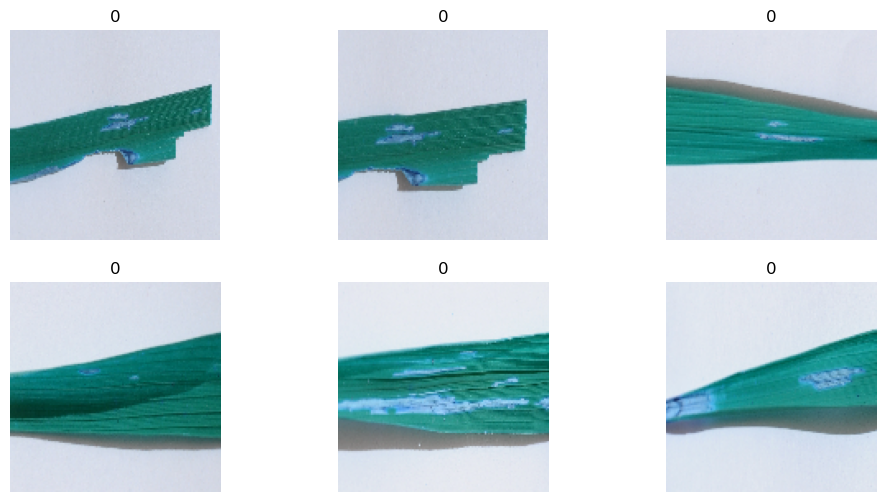

In [16]:
plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X[i])
    plt.title(y[i])
    plt.axis('off')
plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
y_train = to_categorical(y_train, 3)
y_test = to_categorical(y_test, 3)

In [19]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

In [20]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))

In [21]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
6/6 [==============================] - 7s 548ms/step - loss: 1.3050 - accuracy: 0.4316 - val_loss: 1.1624 - val_accuracy: 0.2917
Epoch 2/20
6/6 [==============================] - 3s 404ms/step - loss: 1.1028 - accuracy: 0.3789 - val_loss: 1.0990 - val_accuracy: 0.3333
Epoch 3/20
6/6 [==============================] - 2s 380ms/step - loss: 1.0861 - accuracy: 0.3474 - val_loss: 1.0771 - val_accuracy: 0.2917
Epoch 4/20
6/6 [==============================] - 3s 403ms/step - loss: 1.0519 - accuracy: 0.5053 - val_loss: 1.0733 - val_accuracy: 0.3750
Epoch 5/20
6/6 [==============================] - 3s 394ms/step - loss: 1.0694 - accuracy: 0.4316 - val_loss: 1.0112 - val_accuracy: 0.4583
Epoch 6/20
6/6 [==============================] - 3s 387ms/step - loss: 1.0418 - accuracy: 0.4421 - val_loss: 1.0218 - val_accuracy: 0.4167
Epoch 7/20
6/6 [==============================] - 3s 429ms/step - loss: 1.0119 - accuracy: 0.4737 - val_loss: 0.9694 - val_accuracy: 0.5417
Epoch 8/20
6/6 [====

In [23]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

1/1 [==============================] - 0s 87ms/step - loss: 0.5957 - accuracy: 0.7500
Accuracy: 0.75


In [24]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

1/1 [==============================] - 0s 215ms/step


In [25]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.58      1.00      0.74         7
           1       0.83      0.62      0.71         8
           2       1.00      0.67      0.80         9

    accuracy                           0.75        24
   macro avg       0.81      0.76      0.75        24
weighted avg       0.82      0.75      0.75        24



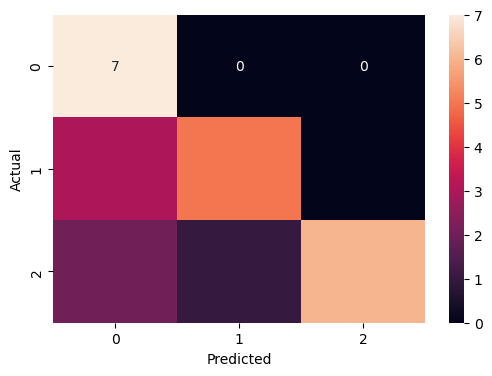

In [26]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
from sqlalchemy import create_engine

engine = create_engine('sqlite:///riceleaf_project.db')

In [28]:
result_df = pd.DataFrame({
    'Actual': y_true,
    'Predicted': y_pred_classes
})

result_df.to_sql('model_results', engine, if_exists='replace', index=False)

24

In [29]:
query = "SELECT Actual, COUNT(*) as count FROM model_results GROUP BY Actual"
pd.read_sql(query, engine)

,Actual,count
0,0,7
1,1,8
2,2,9


In [30]:
query = "SELECT Predicted, COUNT(*) as count FROM model_results GROUP BY Predicted"
pd.read_sql(query, engine)

,Predicted,count
0,0,12
1,1,6
2,2,6


In [31]:
query = "SELECT * FROM model_results LIMIT 10"
pd.read_sql(query, engine)

,Actual,Predicted
0,1,1
1,2,0
2,0,0
3,1,1
4,0,0
5,2,2
6,1,0
7,0,0
8,2,2
9,1,0


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_flat = X.reshape(len(X), -1)

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_flat, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier()
rf.fit(X_train_rf, y_train_rf)

pred_rf = rf.predict(X_test_rf)
print("RF Accuracy:", accuracy_score(y_test_rf, pred_rf))

RF Accuracy: 0.7083333333333334


In [33]:
result_df.to_csv("riceleaf_results.csv", index=False)

In [34]:
import os
print(os.getcwd())

C:\Users\jyoti\Documents\Datamites


In [35]:
os.listdir()

['.ipynb_checkpoints',
 'riceleaf_project.db',
 'riceleaf_results.csv',
 'Untitled.ipynb']

In [36]:
import pandas as pd
df = pd.read_csv("riceleaf_results.csv")

In [37]:
df.to_csv(r"C:\Users\jyoti\OneDrive\Desktop\data.csv", index=False)

In [38]:
df.to_csv("riceleaf_results.csv", index=False)

In [39]:
label_map = {
    0: "Bacterial leaf blight",
    1: "Brown spot",
    2: "Leaf smut"
}

result_df["Disease Name"] = result_df["Actual"].map(label_map)

result_df.to_csv("riceleaf_results.csv", index=False)

In [40]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\jyoti\anaconda3\python.exe
3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]


In [41]:
import tensorflow as tf
print(tf.__version__)

2.13.0


In [42]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\jyoti\Documents\Datamites
['.ipynb_checkpoints', 'riceleaf_project.db', 'riceleaf_results.csv', 'Untitled.ipynb']


In [44]:
import os

desktop_path = r"C:\Users\jyoti\OneDrive\Desktop\riceleaf_results.csv"
result_df.to_csv(desktop_path, index=False)

print("Saved at:", desktop_path)

Saved at: C:\Users\jyoti\OneDrive\Desktop\riceleaf_results.csv
